In [ ]:
import pandas as pd 

path = 'data/compost_data.csv'

df = pd.read_csv(path)

In [ ]:
df.head(10)

,Day,Temperature,MC(%),pH,C/N Ratio,Ammonia(mg/kg),Nitrate(mg/kg),TN(%),TOC(%),EC(ms/cm),OM(%),T Value,GI(%),Score
0,0,35.463,60.0000,5.7345,26.7755,2515.0,325.49,1.80632,48.365121,1.7846,83.381469,1.000000,32.8821,28.042095
1,3,41.866,56.8814,7.1327,23.0494,3449.1,302.42,1.92498,44.369634,2.4366,76.493249,0.860839,39.4615,36.185328
2,6,59.134,53.0847,7.9646,20.4697,5197.6,243.40,1.83675,37.597721,3.0118,64.818472,0.764494,30.5469,37.074037
3,9,53.119,49.4237,8.1770,18.7500,1940.1,203.99,1.78550,33.478125,3.1566,57.716287,0.700267,63.1219,51.246933
4,12,38.955,45.2203,8.0177,17.0303,814.4,200.52,1.91893,32.679954,3.5596,56.340240,0.636040,79.4691,59.698282
5,15,37.403,41.2881,7.5044,16.2420,263.5,309.81,2.12992,34.594161,4.0488,59.640333,0.606599,87.2100,63.659571
6,20,28.478,32.4746,7.4159,15.5255,167.7,420.59,2.24149,34.800253,3.7828,59.995636,0.579840,94.5193,67.356473
7,25,26.925,25.9661,7.3451,14.9522,167.7,497.05,2.24961,33.636619,3.5742,57.989531,0.558428,95.4555,68.582561
8,0,35.269,57.8305,6.1593,28.2086,2515.0,302.62,1.72506,48.661528,1.9569,83.892473,1.000000,33.3853,28.219512
9,3,46.910,54.3051,7.4159,23.6226,3880.2,312.23,1.79568,42.418630,2.7332,73.129719,0.837425,32.8398,34.830469


In [ ]:
run_1 = df.iloc[:8, :]

In [ ]:
run_1.head(10)

,Day,Temperature,MC(%),pH,C/N Ratio,Ammonia(mg/kg),Nitrate(mg/kg),TN(%),TOC(%),EC(ms/cm),OM(%),T Value,GI(%),Score
0,0,35.463,60.0000,5.7345,26.7755,2515.0,325.49,1.80632,48.365121,1.7846,83.381469,1.000000,32.8821,28.042095
1,3,41.866,56.8814,7.1327,23.0494,3449.1,302.42,1.92498,44.369634,2.4366,76.493249,0.860839,39.4615,36.185328
2,6,59.134,53.0847,7.9646,20.4697,5197.6,243.40,1.83675,37.597721,3.0118,64.818472,0.764494,30.5469,37.074037
3,9,53.119,49.4237,8.1770,18.7500,1940.1,203.99,1.78550,33.478125,3.1566,57.716287,0.700267,63.1219,51.246933
4,12,38.955,45.2203,8.0177,17.0303,814.4,200.52,1.91893,32.679954,3.5596,56.340240,0.636040,79.4691,59.698282
5,15,37.403,41.2881,7.5044,16.2420,263.5,309.81,2.12992,34.594161,4.0488,59.640333,0.606599,87.2100,63.659571
6,20,28.478,32.4746,7.4159,15.5255,167.7,420.59,2.24149,34.800253,3.7828,59.995636,0.579840,94.5193,67.356473
7,25,26.925,25.9661,7.3451,14.9522,167.7,497.05,2.24961,33.636619,3.5742,57.989531,0.558428,95.4555,68.582561


In [ ]:
import matplotlib.pyplot as plt

cols_to_graph = ['Temperature', 'MC(%)', 'Score', 'pH', 'C/N Ratio']


In [ ]:
features = [
    'moisture_active1', 'moisture_active2', 'oxygen', 'co2',
    'temperature_curing1', 'temperature_curing2',
    'moisture_curing1', 'moisture_curing2',
    'methane', 'temperature_active1', 'temperature_active2',
    'temperature_active3', 'temperature_active4'
]

In [ ]:
import numpy as np

DAY_COL = "Day"
TEMP_COL = "Temperature" 
MC_COL = "MC(%)"
DAY_SPLIT = 14 
START_DATE = "2025-01-01"

# adding noise
def add_noise(x, scale=0.03, rng=None):
    rng = rng or np.random.default_rng(42)
    std = np.nanstd(x)
    return x + rng.normal(0.0, scale * (std if std > 0 else 1.0), size=len(x))


def make_daily(df_ideal):
    df = df_ideal[[DAY_COL, TEMP_COL, MC_COL]].copy()
    df[DAY_COL] = pd.to_numeric(df[DAY_COL], errors="coerce")
    df = df.dropna(subset=[DAY_COL]).sort_values(DAY_COL)

    # build full daily integer index
    full_days = pd.RangeIndex(int(df[DAY_COL].min()), int(df[DAY_COL].max()) + 1, 1)
    df_daily = df.set_index(DAY_COL).reindex(full_days)

    # interpolate the ideal curves to daily
    df_daily[TEMP_COL] = df_daily[TEMP_COL].interpolate(method="linear")
    df_daily[MC_COL] = df_daily[MC_COL].interpolate(method="linear")

    df_daily = df_daily.reset_index().rename(columns={"index": DAY_COL})
    return df_daily


def synthesize_gases_simple(
    df: pd.DataFrame,
    day_col: str = "Day",
    temp_col: str = "temperature_active1",
    # CO2: early spike then declines
    co2_peak: float = 0.17,     # ~17% at start
    co2_min: float = 0.04,      # floor ~4%
    co2_decay_k: float = 0.18,  # larger = faster decline
    # O2: inverse of CO2, + ventilation pump effect when too hot
    o2_high: float = 0.21,      # ~21%
    o2_low: float  = 0.12,      # ~12% at trough
    pump_temp_thresh: float = 55.0,  # °C threshold to trigger ventilation
    pump_o2_boost: float = 0.03,     # O2 boost when pump on
    pump_co2_drop: float = 0.03,     # CO2 drop when pump on
    # CH4: constant baseline + single spike near day 15
    ch4_base: float = 0.003,
    ch4_peak: float = 0.10,     # ~10% peak
    ch4_center_day: float = 15.0,
    ch4_sigma: float = 0.7      # spike width (~1–2 days)
) -> pd.DataFrame:
    out = df.copy()
    days = out[day_col].astype(float).values
    n = len(days)

    # --- CO2: early spike then monotone decline ---
    # co2(d) = co2_min + (co2_peak - co2_min) * exp(-k * d)
    co2 = co2_min + (co2_peak - co2_min) * np.exp(-co2_decay_k * np.maximum(days - days.min(), 0.0))
    co2 = np.clip(co2, 0.0, 0.20)

    # --- O2: inverse of CO2 (linear map from co2 to [o2_low, o2_high]) ---
    co2_norm = (co2 - co2_min) / max(co2_peak - co2_min, 1e-9)  # 1 at start, -> 0 as co2 decays
    o2 = o2_high - (o2_high - o2_low) * co2_norm                 # high when co2 low, low when co2 high
    o2 = np.clip(o2, 0.05, 0.21)

    # --- Ventilation pump: when too hot, cools & raises O2, lowers CO2 ---
    if temp_col in out.columns:
        hot = out[temp_col].astype(float).values > pump_temp_thresh
        o2[hot]  = np.clip(o2[hot]  + pump_o2_boost, 0.05, 0.21)
        co2[hot] = np.clip(co2[hot] - pump_co2_drop, 0.00, 0.20)

    # --- CH4: baseline + single Gaussian spike around center_day ---
    ch4 = np.full(n, ch4_base, dtype=float)
    ch4 += ch4_peak * np.exp(-0.5 * ((days - ch4_center_day) / max(ch4_sigma, 1e-6))**2)
    ch4 = np.clip(ch4, 0.0, 0.15)

    out["oxygen"]  = o2
    out["co2"]     = co2
    out["methane"] = ch4
    return out


def inflate_lida_features(df_ideal):
    # make daily timeline with interpolation
    df = make_daily(df_ideal)

    # create a real date column from start data + day offset
    start = pd.to_datetime(START_DATE)
    df['time_stamp'] = start + pd.to_timedelta(df[DAY_COL].astype(int), unit="D")

    # normalized helper series
    temp_base = df[TEMP_COL].astype(float)
    mc_base = (df[MC_COL] / 100.0).astype(float)

    # masks
    m_active = df[DAY_COL] <= DAY_SPLIT
    m_curing = df[DAY_COL] > DAY_SPLIT

    rng = np.random.default_rng(123)

    # -------- Active temperatures (only days <= 14) --------
    # 4 probes with small offsets/noise around the ideal curve
    act1 = temp_base + 0.0
    act2 = temp_base + 0.6
    act3 = temp_base - 0.8
    act4 = temp_base + 0.3

    act1 = add_noise(act1, 0.02, rng)
    act2 = add_noise(act2, 0.02, rng)
    act3 = add_noise(act3, 0.02, rng)
    act4 = add_noise(act4, 0.02, rng)

    # Blank outside the active region
    act1[~m_active] = np.nan
    act2[~m_active] = np.nan
    act3[~m_active] = np.nan
    act4[~m_active] = np.nan

    # -------- Curing temperatures (only days > 14) --------
    # Curing generally cooler than active; shift down a bit
    cur1 = temp_base - 6.0
    cur2 = temp_base - 5.0
    cur1 = add_noise(cur1, 0.02, rng)
    cur2 = add_noise(cur2, 0.02, rng)

    cur1[~m_curing] = np.nan
    cur2[~m_curing] = np.nan

    # -------- Moisture (fractions 0..1) --------
    # Active: two probes close to ideal MC, slightly drier for active
    ma1 = np.clip(add_noise(mc_base - 0.02, 0.03, rng), 0.30, 0.90)
    ma2 = np.clip(add_noise(mc_base + 0.00, 0.03, rng), 0.30, 0.90)
    ma1[~m_active] = np.nan
    ma2[~m_active] = np.nan

    # Curing: slightly wetter than active late phase
    mc1 = np.clip(add_noise(mc_base + 0.03, 0.03, rng), 0.30, 0.95)
    mc2 = np.clip(add_noise(mc_base + 0.04, 0.03, rng), 0.30, 0.95)
    mc1[~m_curing] = np.nan
    mc2[~m_curing] = np.nan

    # -------- Assemble LIDA feature columns --------
    out = df[[DAY_COL]].copy()
    out["temperature_active1"] = act1
    out["temperature_active2"] = act2
    out["temperature_active3"] = act3
    out["temperature_active4"] = act4
    out["temperature_curing1"] = cur1
    out["temperature_curing2"] = cur2

    out["moisture_active1"] = ma1 * 100
    out["moisture_active2"] = ma2 * 100
    out["moisture_curing1"] = mc1 * 100
    out["moisture_curing2"] = mc2 * 100

    # Gas placeholders (we'll fill later)
    out["oxygen"]  = np.nan
    out["co2"]     = np.nan
    out["methane"] = np.nan

    # >>> synthesize gases (simple rules: CO2 spike then decline, O2 inverse + pump, CH4 single spike)
    out = synthesize_gases_simple(
        out,
        day_col=DAY_COL,
        temp_col="temperature_active1",   # used to trigger ventilation pump
        pump_temp_thresh=55.0,            # adjust if you want the pump more/less sensitive
        pump_o2_boost=0.03,
        pump_co2_drop=0.03,
        ch4_center_day=15.0               # spike around day 15
    )

    return out

In [ ]:
lida_df = inflate_lida_features(run_1)

In [ ]:
lida_df.head(50)

,Day,temperature_active1,temperature_active2,temperature_active3,temperature_active4,temperature_curing1,temperature_curing2,moisture_active1,moisture_active2,moisture_curing1,moisture_curing2,oxygen,co2,methane
0,0,35.267501,36.316367,34.668588,35.788367,NaN,NaN,57.971782,60.067442,NaN,NaN,NaN,NaN,NaN
1,1,37.524641,38.409615,36.808272,37.752215,NaN,NaN,57.082293,58.722955,NaN,NaN,NaN,NaN,NaN
2,2,39.986224,40.409268,38.836486,39.909030,NaN,NaN,56.066820,57.375116,NaN,NaN,NaN,NaN,NaN
3,3,41.904339,42.467011,40.950690,42.326743,NaN,NaN,54.898553,56.628448,NaN,NaN,NaN,NaN,NaN
4,4,47.803883,48.150497,46.651595,48.246501,NaN,NaN,53.004872,55.957362,NaN,NaN,NaN,NaN,NaN
5,5,53.492064,53.734845,52.283863,53.633232,NaN,NaN,52.284912,54.246294,NaN,NaN,NaN,NaN,NaN
6,6,59.008203,59.976363,58.376753,59.305930,NaN,NaN,50.839361,52.981348,NaN,NaN,NaN,NaN,NaN
7,7,57.236117,57.299697,56.523561,57.372992,NaN,NaN,49.829142,52.344201,NaN,NaN,NaN,NaN,NaN
8,8,55.061425,55.650841,54.216660,55.227313,NaN,NaN,48.957636,50.800162,NaN,NaN,NaN,NaN,NaN
9,9,53.055280,53.751490,52.208590,53.365067,NaN,NaN,47.678303,49.645873,NaN,NaN,NaN,NaN,NaN


In [ ]:
lida_df.to_csv("ideal_inflated_data.csv", index=False)

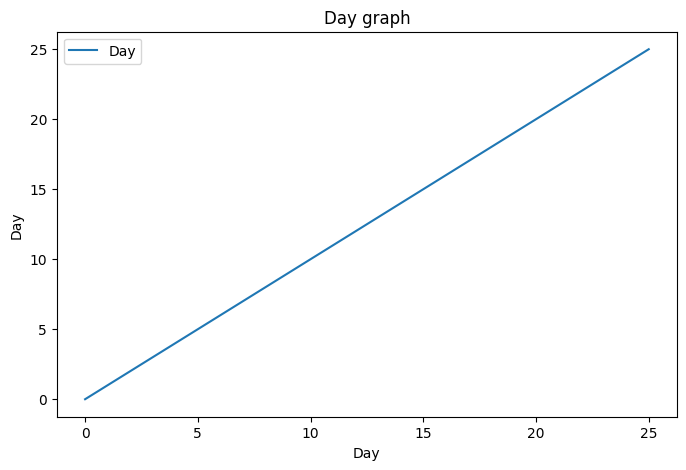

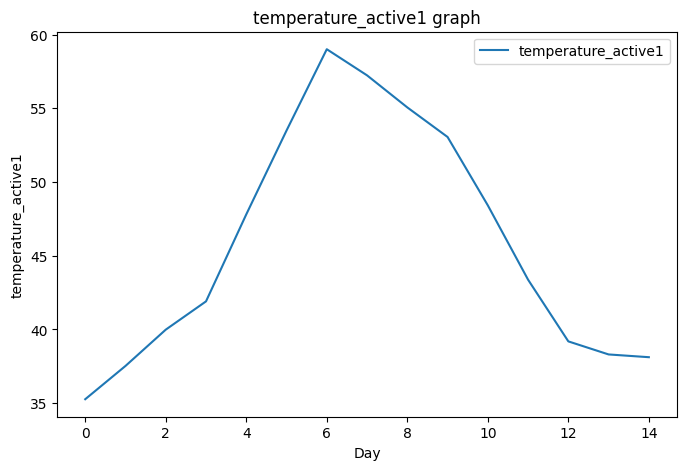

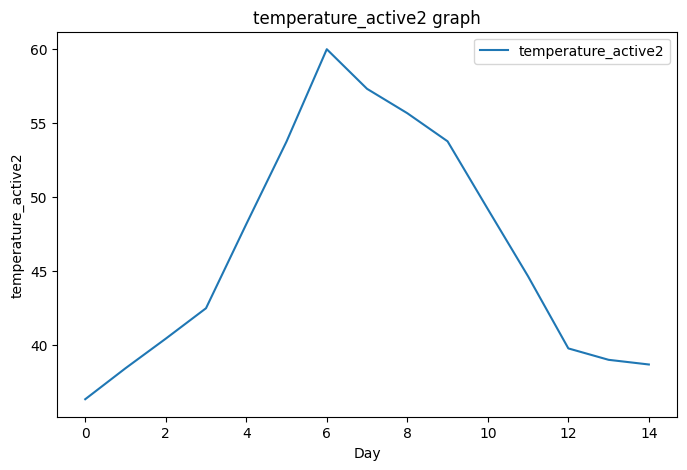

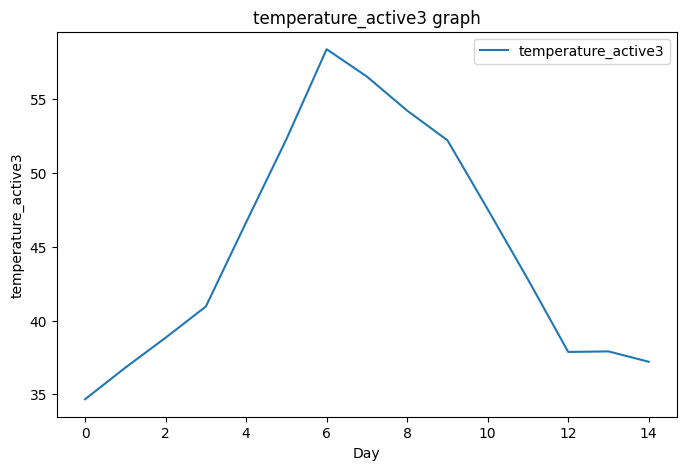

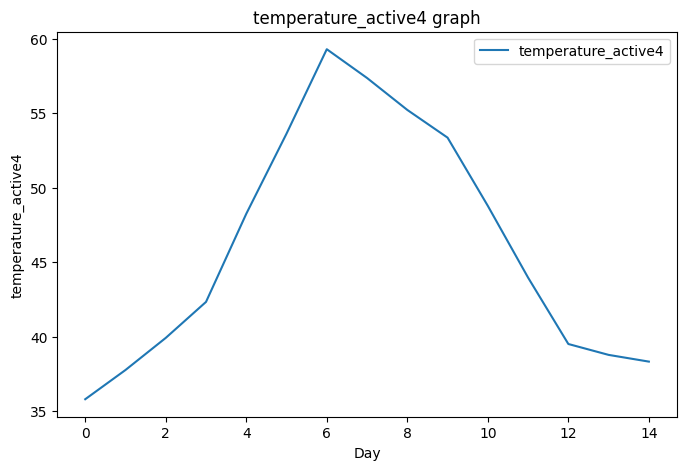

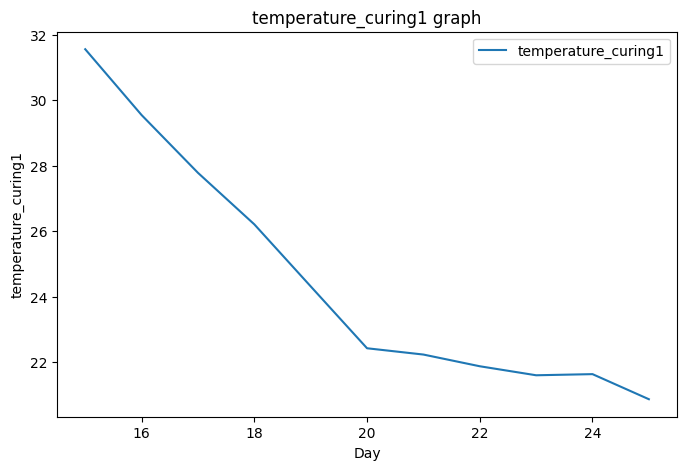

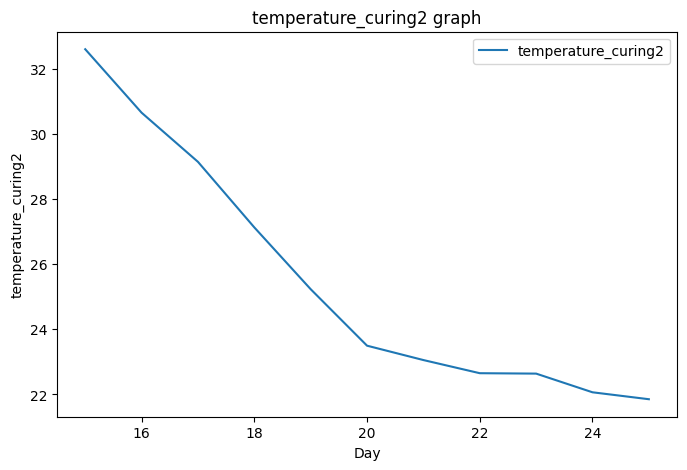

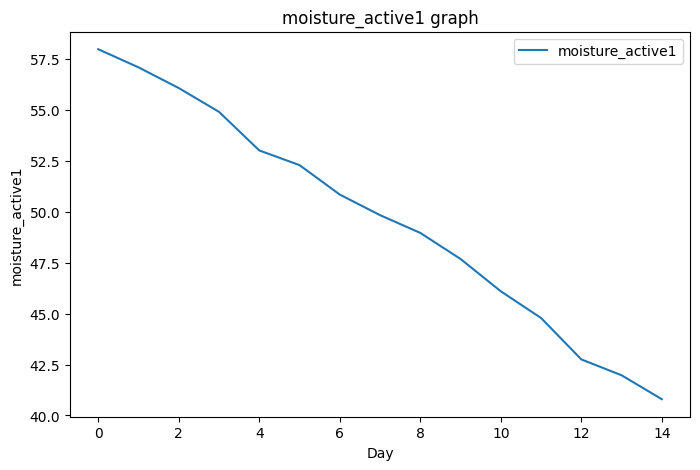

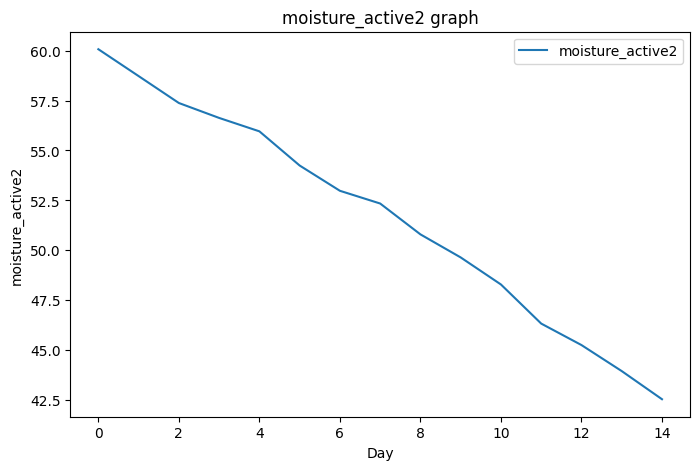

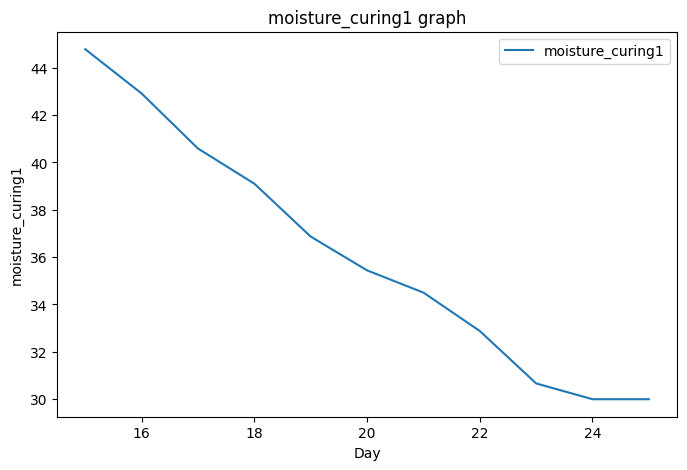

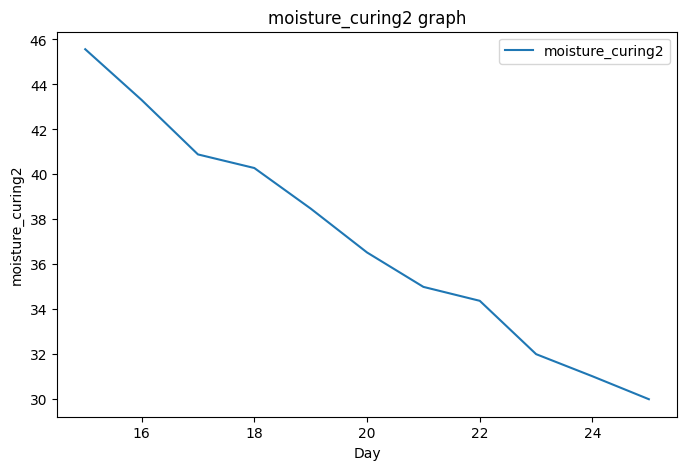

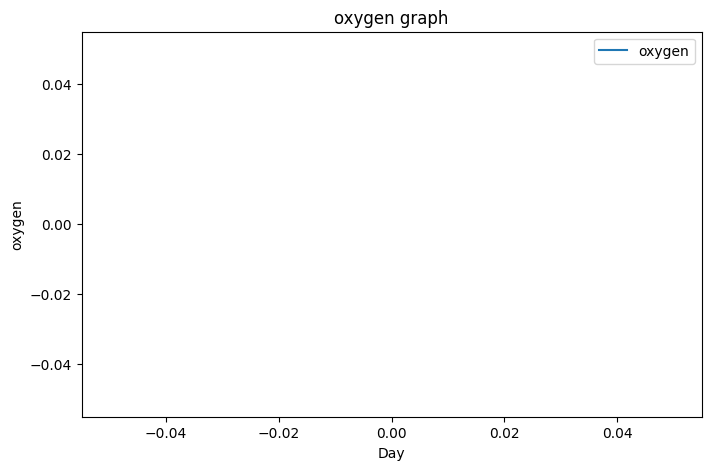

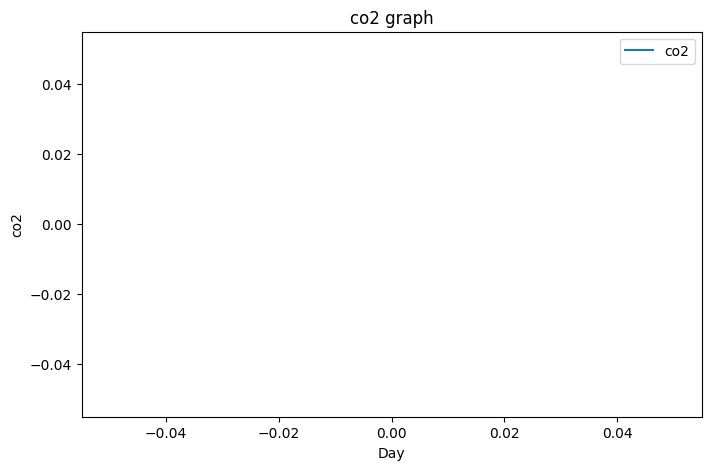

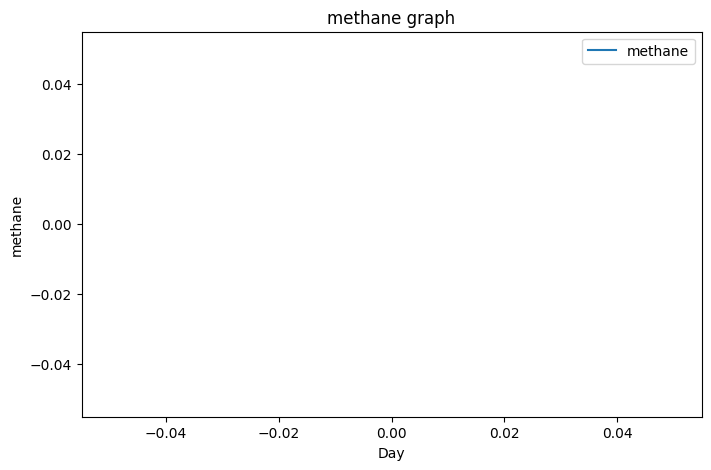

In [ ]:
for col in lida_df.columns:
    plt.figure(figsize=(8,5))
    plt.plot(lida_df.Day, lida_df[col], label=col)
    plt.title(f"{col} graph")
    plt.xlabel("Day")
    plt.ylabel(col)
    plt.legend()
    plt.show()